# 9-4-25 Introduction

What is the question we are trying to answer, what is data? Where does it come from? What questions can it answer?

What is the right kind of analysis

Analysed GDP v. Life Expectancy, Trump v. Biden WI votes. 

* choropleth map: encodes both categorical (candidate) and quantitative (margin of victory) information.

Discussion posts- find visualizations in the wild
Exams- Paper pencil, no specific perfect code, psuedo code, etc.

Project- Groups of 2-4, data visualizations, 1500 word report. 
Jupyter Notebook for technical details, intermediate deliverables.

In [1]:
import pandas as pd                    # the workhorse data package

import pandas_datareader.data as web   # for FRED data calls
import matplotlib.pyplot as plt        # for plots
import datetime as dt                  # for dates

# IPython command to include plots in the notebook
%matplotlib inline
# Create datetime object to hold the begin date
start = dt.datetime(1990, 1, 1)

# Get monthly Yuan-per-dollar exchange rate. 'fred' tells the data reader to use the FRED repository.
# 'EXCHUS' is the name of the data series in FRED. You can find the series codes (names) on the FRED website.
exchus = web.DataReader('EXCHUS', 'fred', start)

# Print out the first 3 observations.
print(exchus.head(3))

# Print out the last 3 observations.
print(exchus.tail(3))

            EXCHUS
DATE              
1990-01-01  4.7339
1990-02-01  4.7339
1990-03-01  4.7339
            EXCHUS
DATE              
2025-07-01  7.1741
2025-08-01  7.1727
2025-09-01  7.1235


In [2]:
# Create datetime object to hold the begin date
start = dt.datetime(1990, 1, 1)

# Get monthly Yuan-per-dollar exchange rate. 'fred' tells the data reader to use the FRED repository.
# 'EXCHUS' is the name of the data series in FRED. You can find the series codes (names) on the FRED website.
exchus = web.DataReader('EXCHUS', 'fred', start)

# Print out the first 3 observations.
print(exchus.head(3))

# Print out the last 3 observations.
print(exchus.tail(3))

            EXCHUS
DATE              
1990-01-01  4.7339
1990-02-01  4.7339
1990-03-01  4.7339
            EXCHUS
DATE              
2025-07-01  7.1741
2025-08-01  7.1727
2025-09-01  7.1235


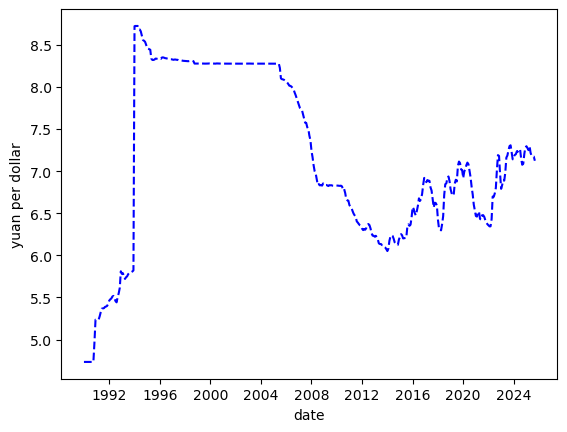

In [3]:
# The basic plotting command. The 'b--' means 'make the line blue and dashed.'
plt.plot(exchus.index, exchus['EXCHUS'], 'b--')
plt.xlabel('date')              # Label the axes
plt.ylabel('yuan per dollar')
plt.show()

In [4]:
# Make list with the names of the data we would like to plot.
ctry_list = ['EXCHUS', 'EXJPUS', 'EXCAUS', 'EXUSEU']   # China, Japan, Canada, Euro

# Make a list of the units for the y axis.
units = ['yuan per USD', 'yen per USD', 'CAD per USD', 'USD per Euro']

# Read the data. Pass a list of codes rather than a single string.
ex_many = web.DataReader(ctry_list, 'fred', start)
print(ex_many)


            EXCHUS    EXJPUS  EXCAUS  EXUSEU
DATE                                        
1990-01-01  4.7339  144.9819  1.1720     NaN
1990-02-01  4.7339  145.6932  1.1965     NaN
1990-03-01  4.7339  153.3082  1.1800     NaN
1990-04-01  4.7339  158.4586  1.1641     NaN
1990-05-01  4.7339  154.0441  1.1747     NaN
...            ...       ...     ...     ...
2025-05-01  7.2166  144.8762  1.3867  1.1274
2025-06-01  7.1804  144.4835  1.3668  1.1534
2025-07-01  7.1741  147.2014  1.3691  1.1671
2025-08-01  7.1727  147.4786  1.3797  1.1647
2025-09-01  7.1235  147.8629  1.3834  1.1739

[429 rows x 4 columns]


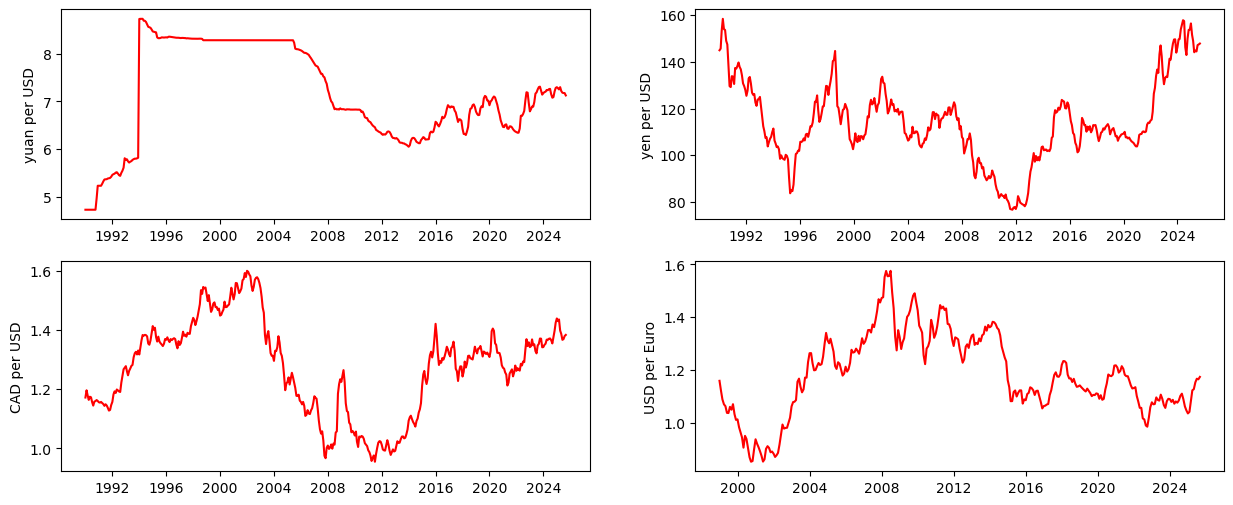

In [5]:
fig, ax = plt.subplots(2, 2, figsize=(15,6))

for ctry, unit, axi in zip(ctry_list, units, fig.axes):
    axi.plot(ex_many.index, ex_many[ctry], 'r-')
    axi.set_ylabel(unit)
